# Evaluating the Impact of Timed Entry at Rocky Mountain National Park

### 1. Research Question

Did Rocky Mountain National Park's timed-entry reservation system reduce visitor crowding?

To answer this question, I used a synthetic control approach to estimate how RMNP visitation may have changed if timed entry had not been implemented.

A weighted combination of comparable National Parks was used to create a "synthetic RMNP" counterfactual.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# plotting style
plt.rcParams.update({
    "font.size": 12,
    "axes.linewidth": 1.5,
    'figure.figsize' : [10.0, 3.0],
    'figure.dpi' :300,
    'image.aspect': 7 })

### 2. Load results 

In [15]:
########################################################################
DATA_PATH = '../data/'
FIGURE_PATH = '../figures/'
RAW_FILE =  DATA_PATH+'raw/Main_Data.xls'
PARKS_FILE =  DATA_PATH+'raw/national_parks_lookup.csv'

VISITS_FILE =  DATA_PATH+'processed/monthly_visitation.csv'
INTERVENTION_FILE =  DATA_PATH+'processed/park_intervention_flags.csv'

DONOR_FILE = DATA_PATH+'processed/donor_pool.csv'
RESULTS_FILE = DATA_PATH+'processed/synthetic_results.csv'
WEIGHTS_FILE = DATA_PATH+'processed/synthetic_weights.csv'
PLACEBO_FILE = DATA_PATH+'processed/placebo_results.csv'

########################################################################
results = pd.read_csv( RESULTS_FILE)

weights = pd.read_csv(WEIGHTS_FILE)

placebos = pd.read_csv(PLACEBO_FILE)

### 3. Main Findings: Actual vs. Synthetic RMNP  

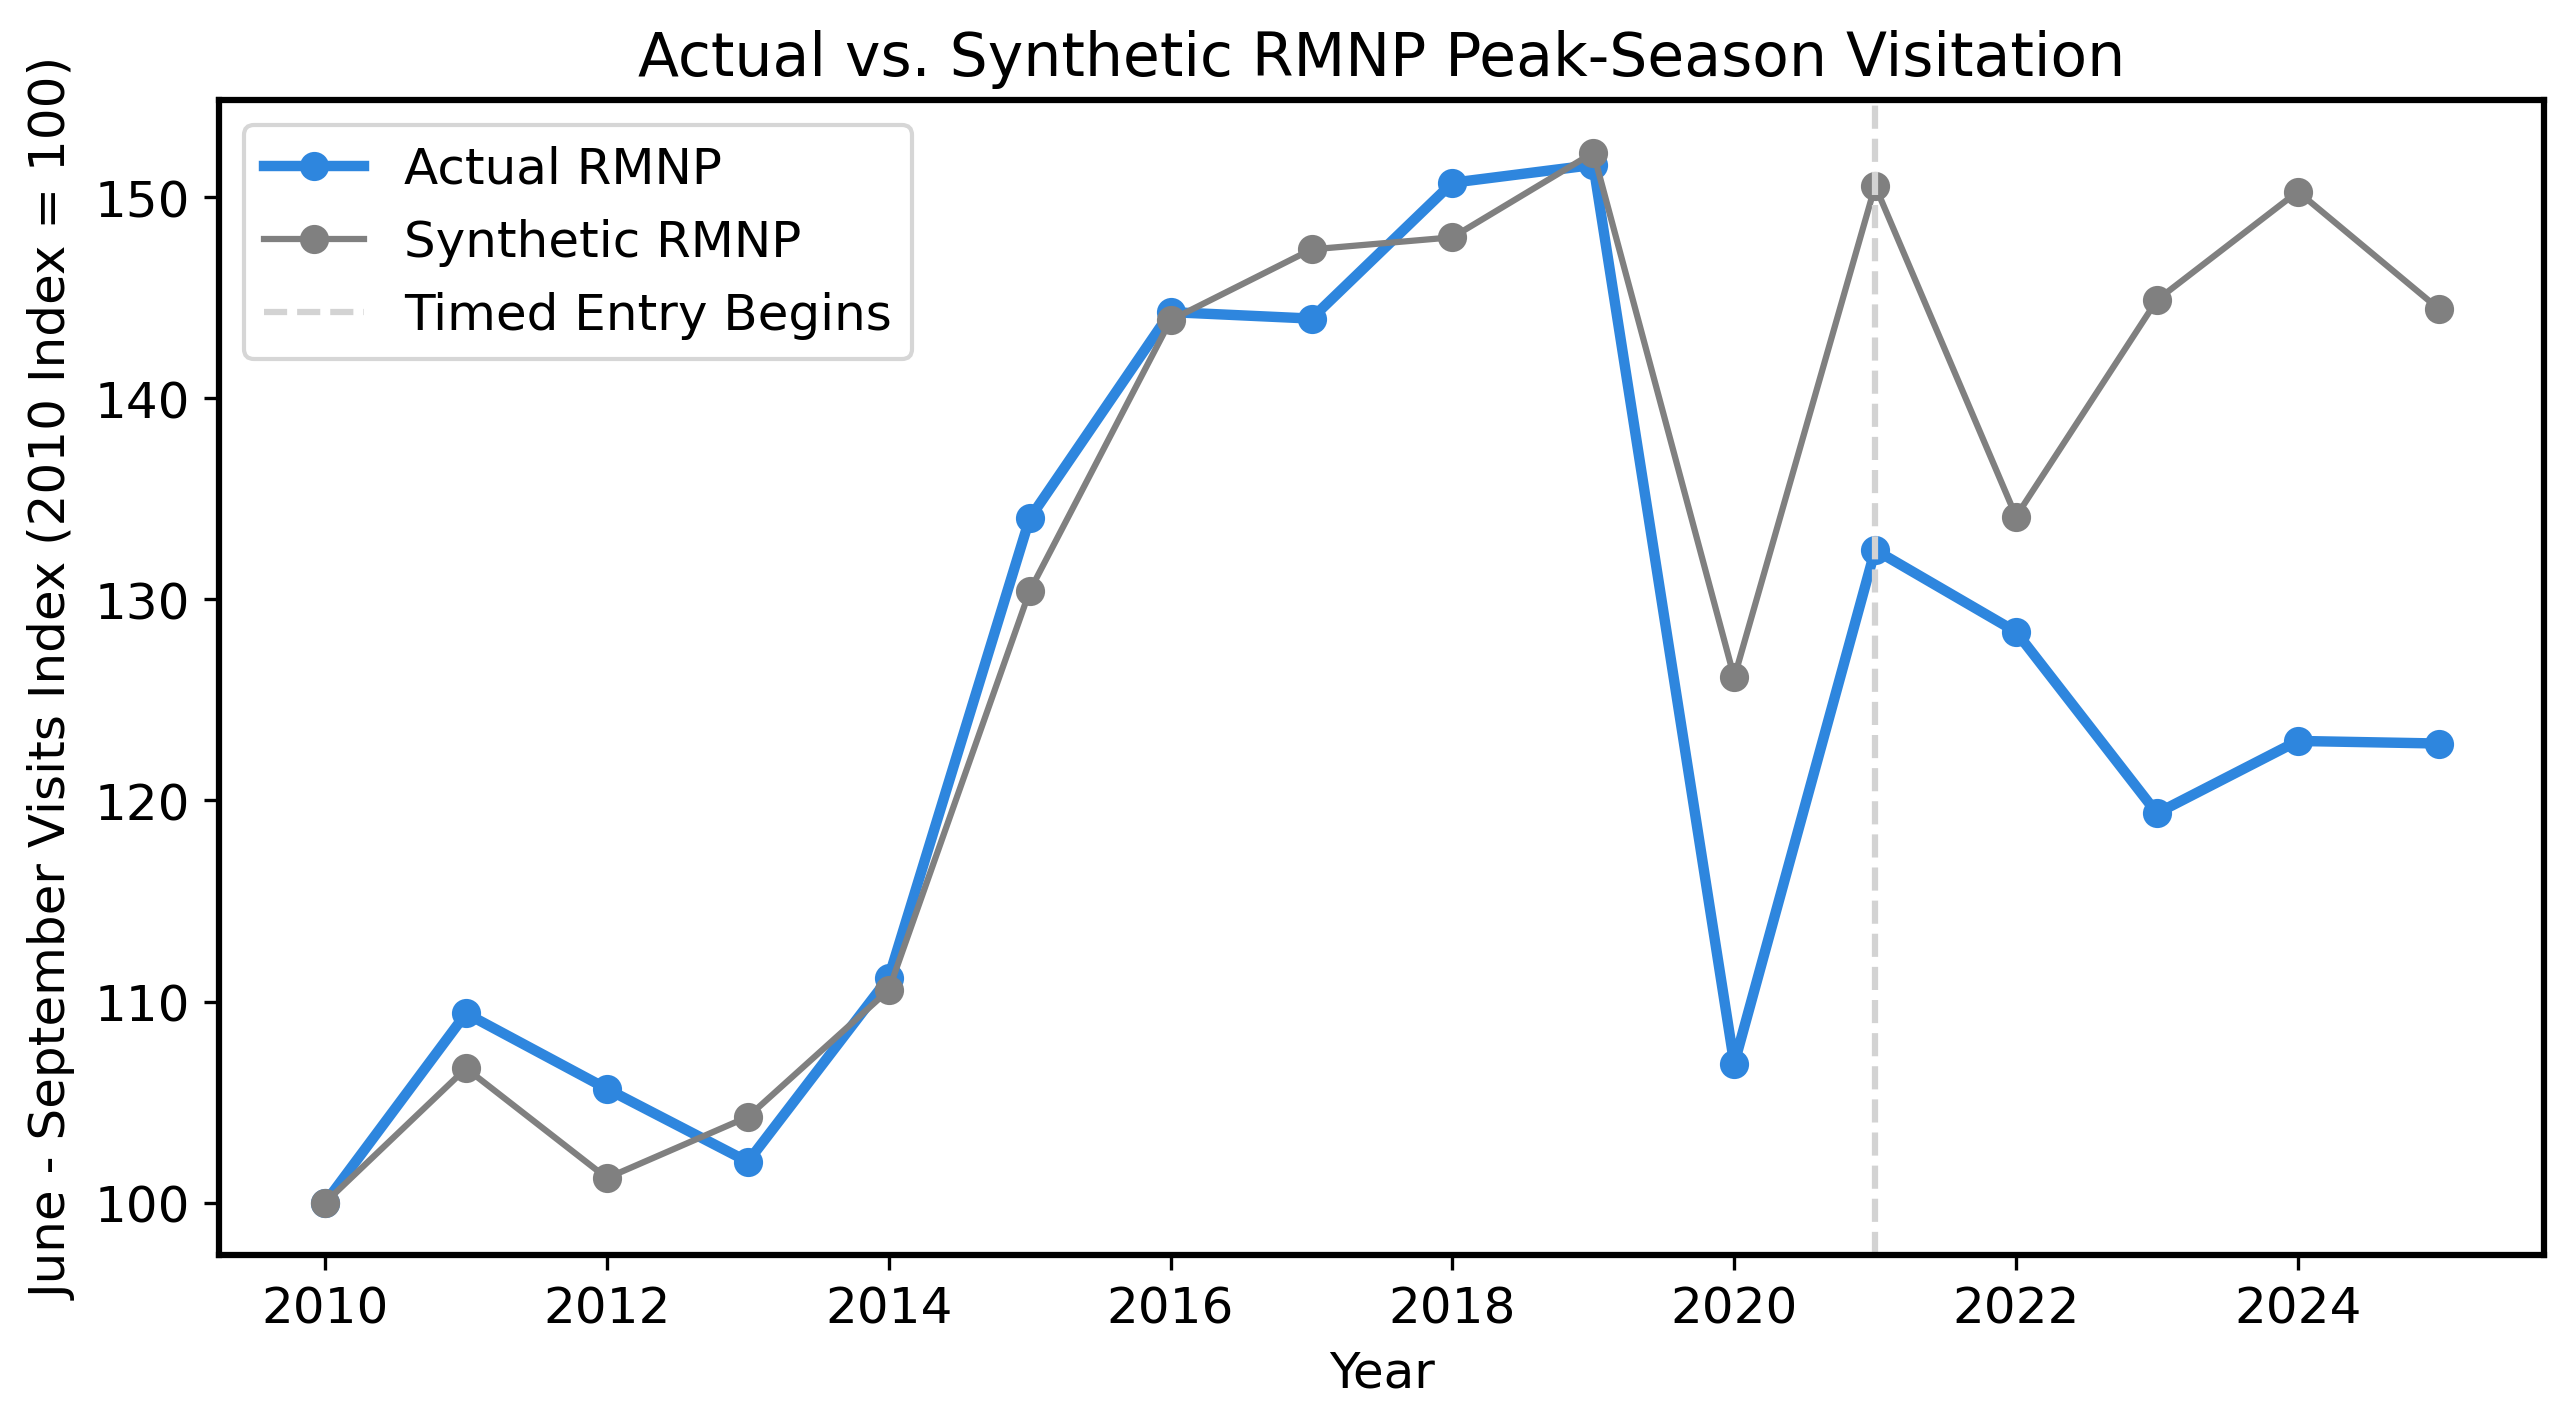

In [16]:
plt.figure(figsize=(10,5))
plt.plot(results["year"], results["actual_rmnp"], marker = "o", lw = 2.5, label = "Actual RMNP", color = "#2E86DE")
plt.plot(results["year"], results["synthetic_rmnp"], marker ="o", label = "Synthetic RMNP", color = 'gray')

plt.axvline(2021, linestyle="--", c="lightgray", label="Timed Entry Begins")

plt.ylabel ("June - September Visits Index (2010 Index = 100)")
plt.title("Actual vs. Synthetic RMNP Peak-Season Visitation")
plt.xlabel("Year")
plt.legend()
plt.show()

Before timed entry, synthetic RMNP closely tracked actual visitation patterns, suggesting the donor parks provided a reasonable counterfactual.

After implementation, RMNP visitation fell below the synthetic estimate, indicating lower-than-expected visitation relative to comparable parks.

### 4. Estimate Effect Size 

In [22]:
post = results[results["year"]>=2021]
avg_effect = (post["effect"].mean())
percent_effect = ((post["actual_rmnp"]-post["synthetic_rmnp"])/post["synthetic_rmnp"]*100).mean()

avg_effect, percent_effect

(np.float64(-19.659747222807443), np.float64(-13.411980096045687))

Following implementation, RMNP experienced 13.4% lower peak-season visitation relative to its synethetic counterfactual after timed entry implementation. 

### 5. Donor composition 

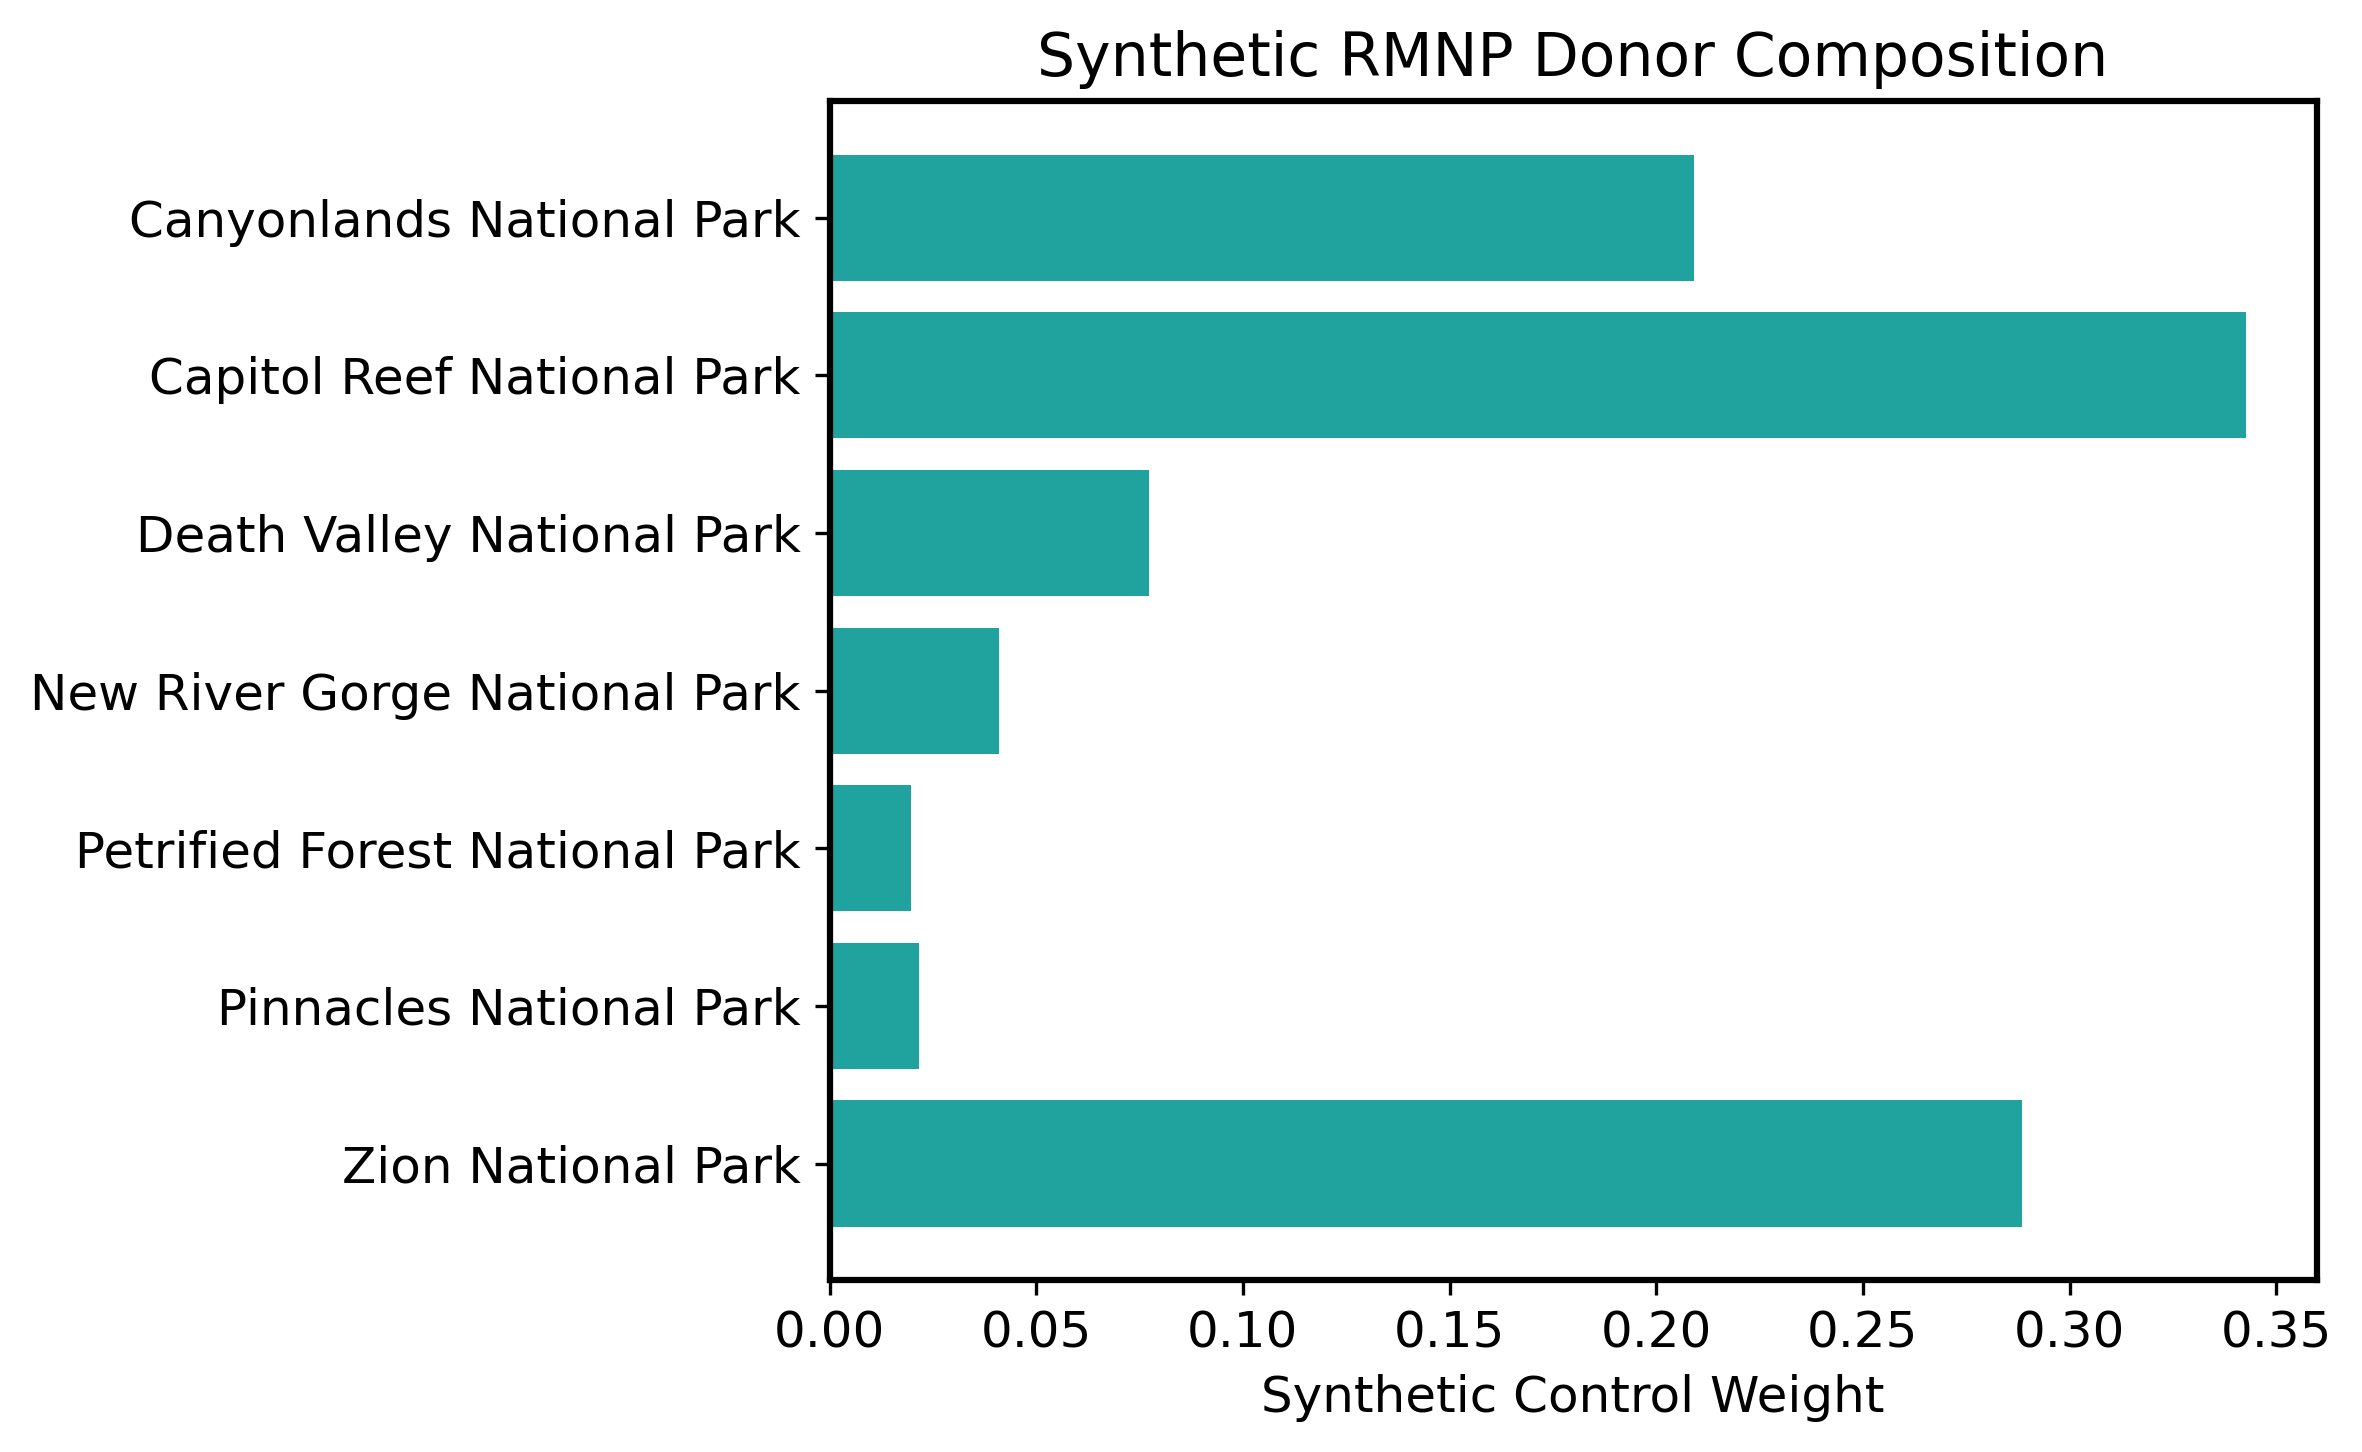

In [18]:
weights_df = pd.read_csv(WEIGHTS_FILE)

top_weights = weights_df[weights_df["weight"] > 0.01]

plt.figure(figsize=(8,5))
plt.title("Synthetic RMNP Donor Composition")
plt.xlabel("Synthetic Control Weight")
plt.barh(top_weights["park_name"],top_weights["weight"], color ='#20a39e')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Synthetic RMNP was primarily constructed from western, road-accessible parks with similar visitation growth patterns, including Capitol Reef, Canyonlands, and Zion.

### 6: What Created Synthetic RMNP? Validation Summary Table 

##### Validation Summary

| **Validation Test** | **Result** | **Interpretation** |
|---|---:|---|
| Pre-treatment RMSE | 2.55 | Synthetic RMNP closely matched actual RMNP before timed entry |
| Post/Pre Gap Ratio | 9.6 | Post-treatment divergence was much larger than normal model error |
| Two-sided Placebo Test | 0.286 | RMNP's overall change was not extreme compared with broader park visitation changes |
| Directional Placebo Test | 0.107 | Few comparable parks experienced declines as large as RMNP |
| Donor Pool Sensitivity | Stable | Estimated effect remained similar across alternative donor pools |
| Time Window Sensitivity | Stable | Results were consistent using different pre-treatment periods |
| Outcome Sensitivity | Stable | Findings were tested across alternative definitions of visitation impact |

### 7: Policy Interpretation

##### Key Insight

Timed entry was associated with reduced visitation volume rather than redistribution of visitors.

Outcome sensitivity testing showed:

- Peak-season visitation decreased by ~13%
- Annual visitation decreased by ~17%
- Peak-season share did not decrease

This suggests timed entry reduced the number of visits but did not substantially shift visitation away from the busiest months.

### 8: Limitations 

- **COVID Effect**: The first year of timed entry overlapped with pandemic-related visitation disruptions. Therefore, 2020 was excluded from effect estimation.

- **Number of visitation does not equal crowding**: Entrance counts do not directly measure parking availability, trail congestion, or visitor experience.

  
- **Synthetitc Control Assumputions**: The approach assumes comparable parks approximate how RMNP would have behaved without timed entry.

### 9: Future work
- Analyze model visitor redistribution
- Include campground occupancy
- Parking availbity 
- Study visitor statisfaction
- Economic impacts on gateway communities 